# B2B Lead Scoring: Exploratory Data Analysis

**Objective:** Explore the clean lead dataset to understand patterns, relationships, and key drivers of conversion.

**Business Context:** We now have clean data with powerful derived features. Our goal is to:
- Understand what makes leads convert
- Identify the strongest conversion predictors
- Validate our cleaning insights (form completion, data quality)
- Prepare features for modeling

**Key Questions:**
- What is our overall conversion rate?
- How does form completion impact conversion?
- Which lead sources perform best?
- Does sales engagement improve conversion?
- What behavioral patterns predict conversion?


## 1. Setup & Load Clean Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set visualization style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# Load CLEAN dataset (created in Notebook 00)
df = pd.read_csv('../data/Leads_clean.csv')

print(f"Clean dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n✓ Using CLEAN dataset with derived features")

Clean dataset loaded: 9,240 rows × 47 columns
Memory usage: 16.61 MB

✓ Using CLEAN dataset with derived features


In [3]:
# Quick overview
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nShape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

DATASET OVERVIEW

Shape: (9240, 47)

Columns (47):
   1. Prospect ID
   2. Lead Number
   3. Lead Origin
   4. Lead Source
   5. Do Not Email
   6. Do Not Call
   7. Converted
   8. TotalVisits
   9. Total Time Spent on Website
  10. Page Views Per Visit
  11. Last Activity
  12. Country
  13. Specialization
  14. How did you hear about X Education
  15. What is your current occupation
  16. What matters most to you in choosing a course
  17. Search
  18. Magazine
  19. Newspaper Article
  20. X Education Forums
  21. Newspaper
  22. Digital Advertisement
  23. Through Recommendations
  24. Receive More Updates About Our Courses
  25. Tags
  26. Lead Quality
  27. Update me on Supply Chain Content
  28. Get updates on DM Content
  29. Lead Profile
  30. City
  31. Asymmetrique Activity Index
  32. Asymmetrique Profile Index
  33. Asymmetrique Activity Score
  34. Asymmetrique Profile Score
  35. I agree to pay the amount through cheque
  36. A free copy of Mastering The Interview
  37.

In [4]:
# Sample of clean data
print("=" * 80)
print("SAMPLE DATA (First 5 rows)")
print("=" * 80)
df.head()

SAMPLE DATA (First 5 rows)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,has_lead_profile,lead_profile_data_error,has_quality_assessment,quality_data_error,action_status,has_sales_contact,tags_data_error,already_student,form_completion_score,has_asymmetrique_data
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Data Error,Not Specified,Not Specified,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,To Be Determined,Not Specified,02.Medium,02.Medium,15.0,15.0,No,No,Modified,0,0,1,0,Interested - Wrong Timing,1,0,0,0.4,1
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Not Specified,Not Specified,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Data Error,No,No,To Be Determined,Not Specified,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened,0,0,0,1,In Discussion,1,0,0,0.4,1
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Not Specified,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened,1,0,1,0,In Discussion,1,0,0,0.8,1
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,To Be Determined,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified,0,0,1,0,In Discussion,1,0,0,0.8,1
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Not Specified,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,To Be Determined,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified,0,0,1,0,In Discussion,1,0,0,0.6,1


## 2. Target Variable Analysis

Understanding our conversion rate is the foundation of everything.

CONVERSION ANALYSIS

Total Leads: 9,240
Converted: 3,561
Not Converted: 5,679

📊 Overall Conversion Rate: 38.54%


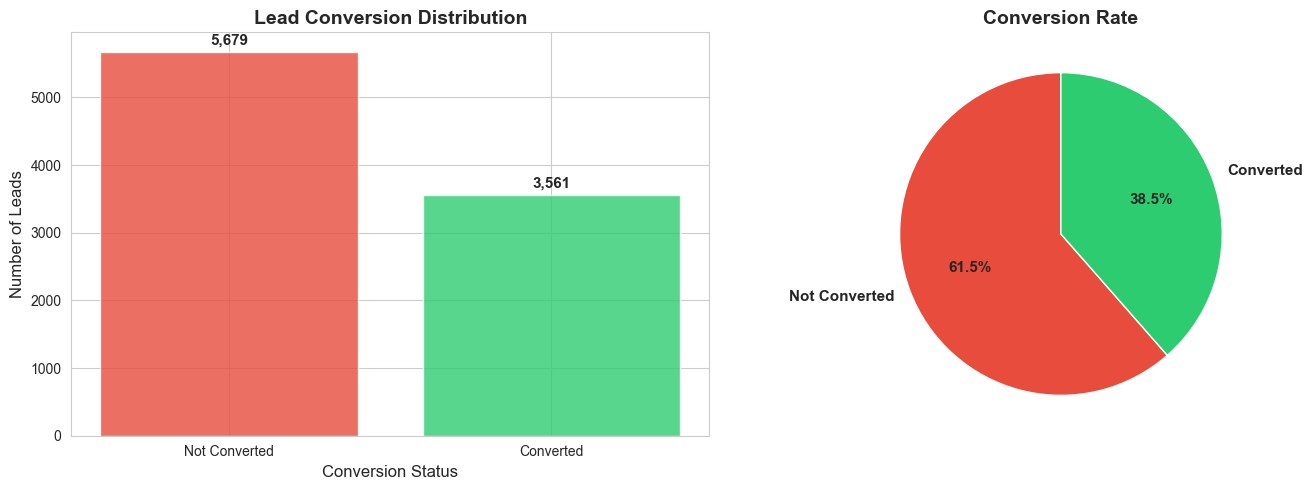


✓ Saved: visualizations/01_conversion_overview.png


In [5]:
# Overall conversion analysis
print("=" * 80)
print("CONVERSION ANALYSIS")
print("=" * 80)

total_leads = len(df)
converted = df['Converted'].sum()
not_converted = total_leads - converted
conversion_rate = (converted / total_leads) * 100

print(f"\nTotal Leads: {total_leads:,}")
print(f"Converted: {converted:,}")
print(f"Not Converted: {not_converted:,}")
print(f"\n📊 Overall Conversion Rate: {conversion_rate:.2f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
conversion_counts = df['Converted'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax1.bar(['Not Converted', 'Converted'], conversion_counts.values, color=colors, alpha=0.8)
ax1.set_title('Lead Conversion Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Leads', fontsize=12)
ax1.set_xlabel('Conversion Status', fontsize=12)

# Add count labels
for i, v in enumerate(conversion_counts.values):
    ax1.text(i, v + 100, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
ax2.pie([not_converted, converted], labels=['Not Converted', 'Converted'], 
        autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Conversion Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/01_conversion_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visualizations/01_conversion_overview.png")

## 3. Form Completion Analysis - KEY INSIGHT

This is the most important finding from our cleaning: form completion strongly predicts conversion.

In [7]:
# Form completion analysis
print("=" * 80)
print("FORM COMPLETION IMPACT ON CONVERSION")
print("=" * 80)

form_analysis = df.groupby('form_completion_score').agg({
    'Converted': ['count', 'sum', 'mean']
}).round(3)

form_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
form_analysis['Conversion_Pct'] = (form_analysis['Conversion_Rate'] * 100).round(2)

print("\nConversion by Form Completion Score:")
print(form_analysis)

# Calculate impact
complete_forms = form_analysis.loc[1.0, 'Conversion_Pct'] if 1.0 in form_analysis.index else 0
incomplete_forms = form_analysis.loc[0.0, 'Conversion_Pct'] if 0.0 in form_analysis.index else 0
difference = complete_forms - incomplete_forms
multiplier = complete_forms / incomplete_forms if incomplete_forms > 0 else 0

print(f"\n💡 KEY INSIGHT:")
print(f"  Fully complete forms (1.0):  {complete_forms:.1f}% conversion")
print(f"  Empty forms (0.0):           {incomplete_forms:.1f}% conversion")
print(f"  Difference:                  {difference:.1f}% ({multiplier:.1f}x higher)")

FORM COMPLETION IMPACT ON CONVERSION

Conversion by Form Completion Score:
                       Total_Leads  Conversions  Conversion_Rate  \
form_completion_score                                              
0.0                           1419          151            0.106   
0.2                            801          133            0.166   
0.4                           2058          811            0.394   
0.6                           1968          654            0.332   
0.8                           2475         1457            0.589   
1.0                            519          355            0.684   

                       Conversion_Pct  
form_completion_score                  
0.0                              10.6  
0.2                              16.6  
0.4                              39.4  
0.6                              33.2  
0.8                              58.9  
1.0                              68.4  

💡 KEY INSIGHT:
  Fully complete forms (1.0):  68.4% convers

So the more the form is complete, the more we can expect a successful completion.

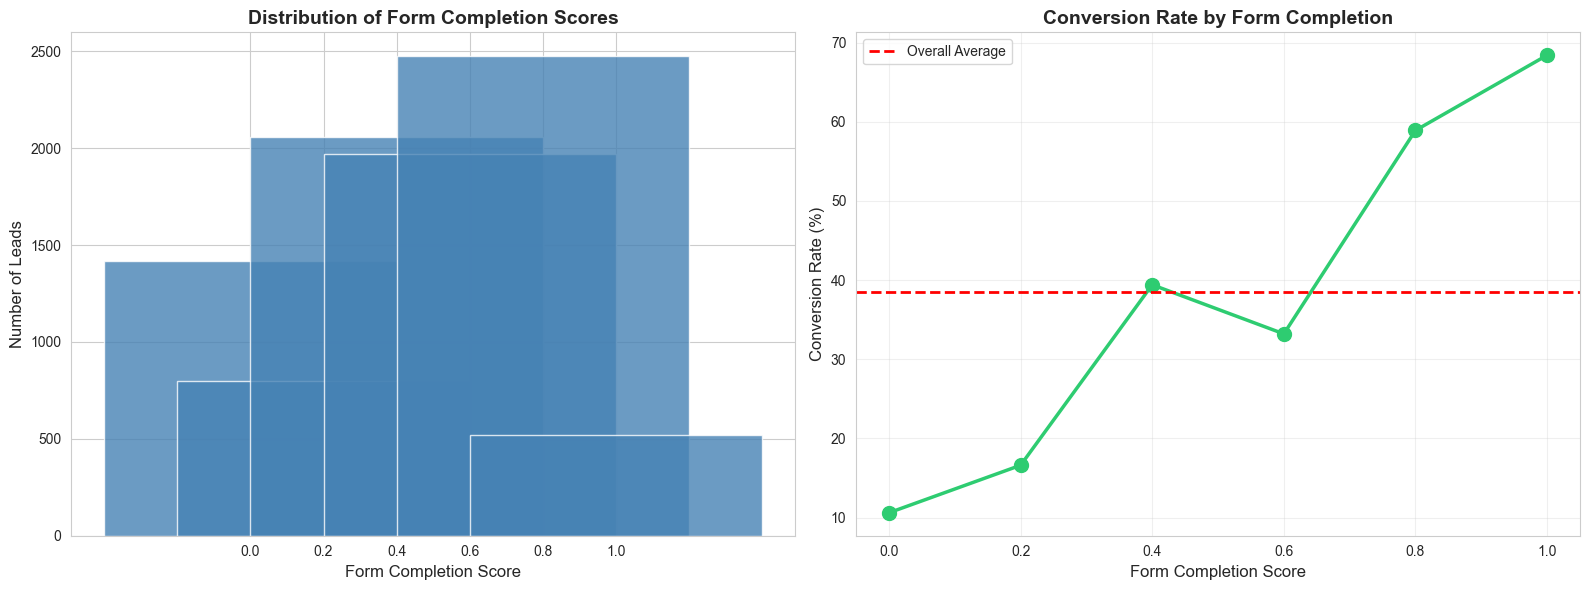

✓ Saved: visualizations/02_form_completion_impact.png


In [8]:
# Visualize form completion impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of completion scores
completion_dist = df['form_completion_score'].value_counts().sort_index()
ax1.bar(completion_dist.index, completion_dist.values, color='steelblue', alpha=0.8)
ax1.set_title('Distribution of Form Completion Scores', fontsize=14, fontweight='bold')
ax1.set_xlabel('Form Completion Score', fontsize=12)
ax1.set_ylabel('Number of Leads', fontsize=12)
ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Conversion rate by completion score
ax2.plot(form_analysis.index, form_analysis['Conversion_Pct'], 
         marker='o', linewidth=2.5, markersize=10, color='#2ecc71')
ax2.set_title('Conversion Rate by Form Completion', fontsize=14, fontweight='bold')
ax2.set_xlabel('Form Completion Score', fontsize=12)
ax2.set_ylabel('Conversion Rate (%)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=conversion_rate, color='red', linestyle='--', linewidth=2, label='Overall Average')
ax2.legend(fontsize=10)
ax2.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tight_layout()
plt.savefig('../visualizations/02_form_completion_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations/02_form_completion_impact.png")

## 4. Lead Source Performance

Which channels bring the highest quality leads?

In [9]:
# Lead source analysis
print("=" * 80)
print("LEAD SOURCE PERFORMANCE")
print("=" * 80)

if 'Lead Source' in df.columns:
    source_analysis = df.groupby('Lead Source').agg({
        'Converted': ['count', 'sum', 'mean']
    }).round(3)
    
    source_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
    source_analysis['Conversion_Pct'] = (source_analysis['Conversion_Rate'] * 100).round(2)
    source_analysis = source_analysis.sort_values('Conversion_Pct', ascending=False)
    
    # Filter to sources with at least 50 leads for statistical significance
    significant_sources = source_analysis[source_analysis['Total_Leads'] >= 50]
    
    print(f"\nTop Lead Sources (minimum 50 leads):")
    print(significant_sources.head(10))
    
    # Identify best and worst performers
    if len(significant_sources) > 0:
        best_source = significant_sources.index[0]
        worst_source = significant_sources.index[-1]
        
        print(f"\n🏆 Best performing source: {best_source}")
        print(f"   {significant_sources.loc[best_source, 'Conversion_Pct']:.1f}% conversion ({significant_sources.loc[best_source, 'Total_Leads']:,.0f} leads)")
        
        print(f"\n⚠️  Worst performing source: {worst_source}")
        print(f"   {significant_sources.loc[worst_source, 'Conversion_Pct']:.1f}% conversion ({significant_sources.loc[worst_source, 'Total_Leads']:,.0f} leads)")

LEAD SOURCE PERFORMANCE

Top Lead Sources (minimum 50 leads):
                  Total_Leads  Conversions  Conversion_Rate  Conversion_Pct
Lead Source                                                                
Welingak Website          142          140            0.986            98.6
Reference                 534          490            0.918            91.8
Google                   2868         1147            0.400            40.0
Organic Search           1154          436            0.378            37.8
Direct Traffic           2543          818            0.322            32.2
Olark Chat               1755          448            0.255            25.5
Referral Sites            125           31            0.248            24.8
Facebook                   55           13            0.236            23.6

🏆 Best performing source: Welingak Website
   98.6% conversion (142 leads)

⚠️  Worst performing source: Facebook
   23.6% conversion (55 leads)


The best source is Welingak website followed by Reference and the worst ones referral sitesolark chat and facebook

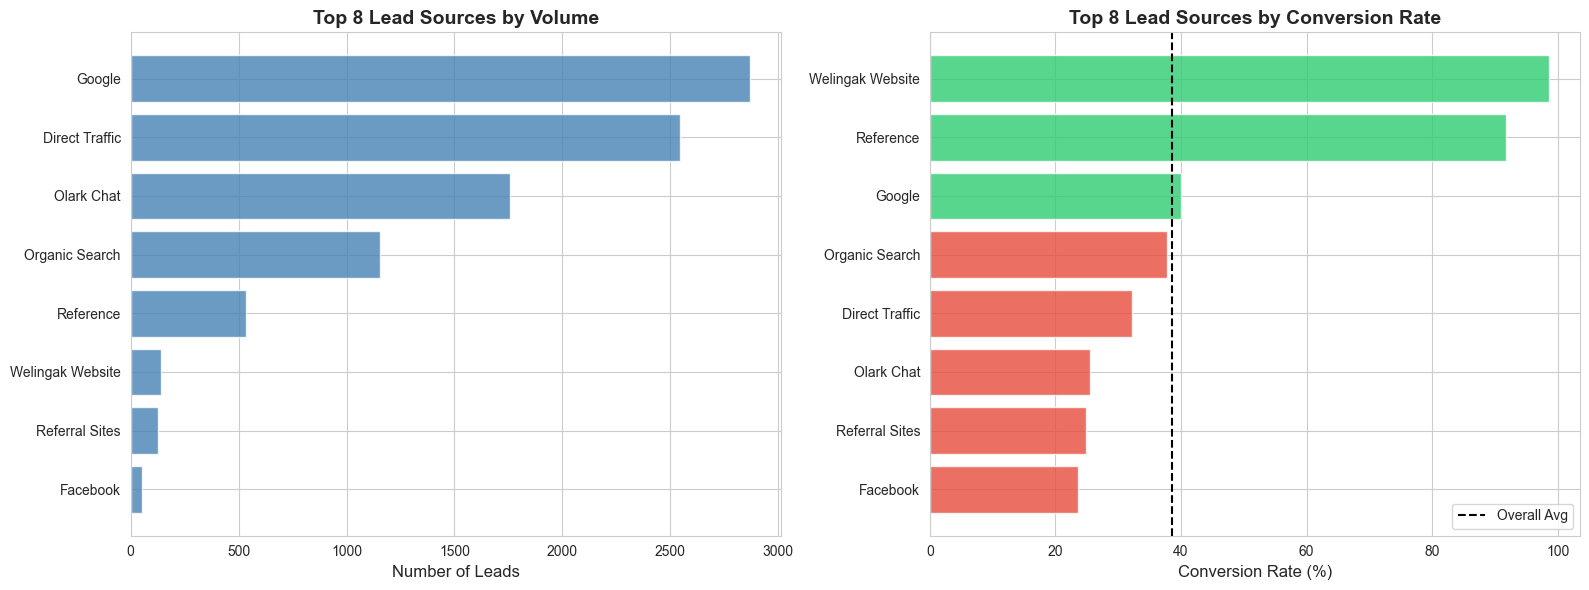

✓ Saved: visualizations/03_lead_source_performance.png


In [10]:
# Visualize lead source performance
if 'Lead Source' in df.columns and len(significant_sources) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top sources by volume
    top_volume = source_analysis.nlargest(8, 'Total_Leads')
    ax1.barh(range(len(top_volume)), top_volume['Total_Leads'], color='steelblue', alpha=0.8)
    ax1.set_yticks(range(len(top_volume)))
    ax1.set_yticklabels(top_volume.index)
    ax1.set_xlabel('Number of Leads', fontsize=12)
    ax1.set_title('Top 8 Lead Sources by Volume', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    
    # Top sources by conversion rate (min 50 leads)
    top_conversion = significant_sources.nlargest(8, 'Conversion_Pct')
    colors_conv = ['#2ecc71' if x > conversion_rate else '#e74c3c' for x in top_conversion['Conversion_Pct']]
    ax2.barh(range(len(top_conversion)), top_conversion['Conversion_Pct'], color=colors_conv, alpha=0.8)
    ax2.set_yticks(range(len(top_conversion)))
    ax2.set_yticklabels(top_conversion.index)
    ax2.set_xlabel('Conversion Rate (%)', fontsize=12)
    ax2.set_title('Top 8 Lead Sources by Conversion Rate', fontsize=14, fontweight='bold')
    ax2.axvline(x=conversion_rate, color='black', linestyle='--', linewidth=1.5, label='Overall Avg')
    ax2.legend()
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('../visualizations/03_lead_source_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: visualizations/03_lead_source_performance.png")

But volume size, Google, Direct traffic and Olark chat are the most interesting ones. This means that Olark Chat and direct traffice needs to improve seriously improved.

## 5. Sales Engagement Analysis

Does sales contact improve conversion? What action statuses perform best?

In [11]:
# Sales contact impact
print("=" * 80)
print("SALES ENGAGEMENT IMPACT")
print("=" * 80)

if 'has_sales_contact' in df.columns:
    contact_analysis = df.groupby('has_sales_contact')['Converted'].agg(['count', 'sum', 'mean'])
    contact_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
    contact_analysis['Conversion_Pct'] = (contact_analysis['Conversion_Rate'] * 100).round(2)
    contact_analysis.index = ['Not Contacted', 'Contacted']
    
    print("\nConversion by Sales Contact Status:")
    print(contact_analysis)
    
    contacted_conv = contact_analysis.loc['Contacted', 'Conversion_Pct']
    not_contacted_conv = contact_analysis.loc['Not Contacted', 'Conversion_Pct']
    
    print(f"\n💡 INSIGHT:")
    print(f"  Contacted leads:     {contacted_conv:.1f}% conversion")
    print(f"  Not contacted leads: {not_contacted_conv:.1f}% conversion")
    print(f"  Impact: {contacted_conv - not_contacted_conv:+.1f}% difference")

SALES ENGAGEMENT IMPACT

Conversion by Sales Contact Status:
               Total_Leads  Conversions  Conversion_Rate  Conversion_Pct
Not Contacted         3353          836         0.249329           24.93
Contacted             5887         2725         0.462884           46.29

💡 INSIGHT:
  Contacted leads:     46.3% conversion
  Not contacted leads: 24.9% conversion
  Impact: +21.4% difference



ACTION STATUS PERFORMANCE

Conversion by Action Status:
                           Total_Leads  Conversions  Conversion_Rate  \
action_status                                                          
In Discussion                     3472         2148            0.619   
Lost                               925          532            0.575   
Not Contacted                     3353          836            0.249   
Other                              133            9            0.068   
Interested - Wrong Timing          526           21            0.040   
Unreachable                        190            4            0.021   
Not Eligible                       641           11            0.017   

                           Conversion_Pct  
action_status                              
In Discussion                        61.9  
Lost                                 57.5  
Not Contacted                        24.9  
Other                                 6.8  
Interested - Wrong Timing     

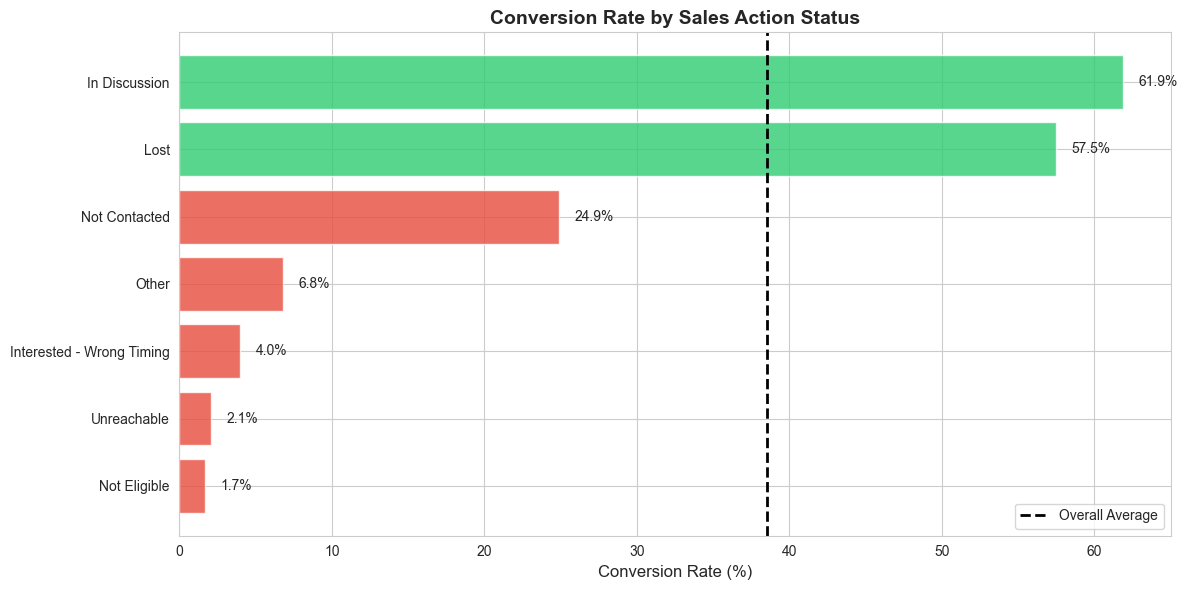


✓ Saved: visualizations/04_action_status_conversion.png


In [12]:
# Action status analysis
print("\n" + "=" * 80)
print("ACTION STATUS PERFORMANCE")
print("=" * 80)

if 'action_status' in df.columns:
    status_analysis = df.groupby('action_status').agg({
        'Converted': ['count', 'sum', 'mean']
    }).round(3)
    
    status_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
    status_analysis['Conversion_Pct'] = (status_analysis['Conversion_Rate'] * 100).round(2)
    status_analysis = status_analysis.sort_values('Conversion_Pct', ascending=False)
    
    print("\nConversion by Action Status:")
    print(status_analysis)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors_status = ['#2ecc71' if x > conversion_rate else '#e74c3c' for x in status_analysis['Conversion_Pct']]
    ax.barh(range(len(status_analysis)), status_analysis['Conversion_Pct'], color=colors_status, alpha=0.8)
    ax.set_yticks(range(len(status_analysis)))
    ax.set_yticklabels(status_analysis.index)
    ax.set_xlabel('Conversion Rate (%)', fontsize=12)
    ax.set_title('Conversion Rate by Sales Action Status', fontsize=14, fontweight='bold')
    ax.axvline(x=conversion_rate, color='black', linestyle='--', linewidth=2, label='Overall Average')
    ax.legend(fontsize=10)
    ax.invert_yaxis()
    
    # Add percentage labels
    for i, v in enumerate(status_analysis['Conversion_Pct']):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../visualizations/04_action_status_conversion.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Saved: visualizations/04_action_status_conversion.png")

the results are a no brainer, contact is always the main source for converting but why lost is the second source of convertion, that's strange.

## 6. Behavioral Metrics Analysis

How do website engagement metrics correlate with conversion?

In [13]:
# Behavioral metrics comparison
print("=" * 80)
print("BEHAVIORAL METRICS: Converted vs Not Converted")
print("=" * 80)

behavioral_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

behavior_comparison = df.groupby('Converted')[behavioral_cols].agg(['mean', 'median']).round(2)

print("\nBehavioral Metrics by Conversion Status:")
print(behavior_comparison)

# Calculate differences
print("\n💡 INSIGHTS:")
for col in behavioral_cols:
    converted_mean = behavior_comparison.loc[1, (col, 'mean')]
    not_converted_mean = behavior_comparison.loc[0, (col, 'mean')]
    diff = converted_mean - not_converted_mean
    pct_diff = (diff / not_converted_mean) * 100 if not_converted_mean > 0 else 0
    
    print(f"\n{col}:")
    print(f"  Converted avg: {converted_mean:.2f}")
    print(f"  Not converted avg: {not_converted_mean:.2f}")
    print(f"  Difference: {diff:+.2f} ({pct_diff:+.1f}%)")

BEHAVIORAL METRICS: Converted vs Not Converted

Behavioral Metrics by Conversion Status:
          TotalVisits        Total Time Spent on Website         \
                 mean median                        mean median   
Converted                                                         
0                3.33    3.0                      330.40  179.0   
1                3.79    3.0                      738.55  832.0   

          Page Views Per Visit         
                          mean median  
Converted                              
0                         2.37    2.0  
1                         2.37    2.0  

💡 INSIGHTS:

TotalVisits:
  Converted avg: 3.79
  Not converted avg: 3.33
  Difference: +0.46 (+13.8%)

Total Time Spent on Website:
  Converted avg: 738.55
  Not converted avg: 330.40
  Difference: +408.15 (+123.5%)

Page Views Per Visit:
  Converted avg: 2.37
  Not converted avg: 2.37
  Difference: +0.00 (+0.0%)


IMPORTANT INFO : Total time spent on website is a real driver for convertion. The more you spent the more you convert. the others are not a marker of successful conversions.

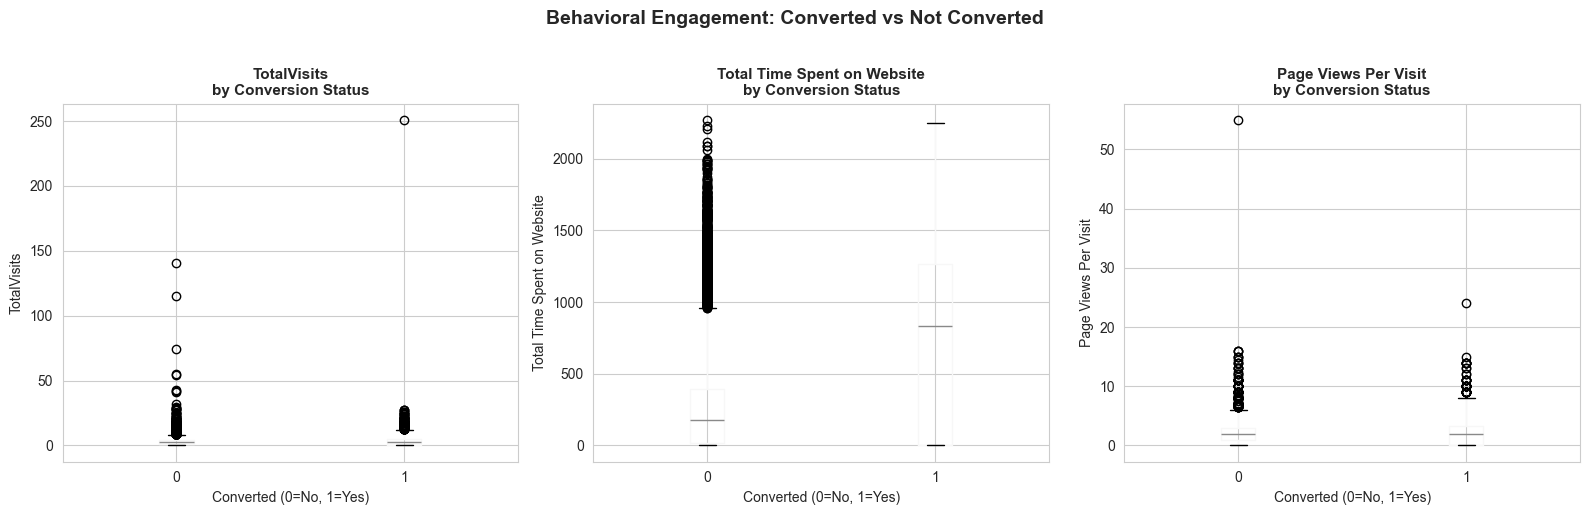

✓ Saved: visualizations/05_behavioral_analysis.png


In [14]:
# Visualize behavioral differences
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(behavioral_cols):
    # Box plot
    df.boxplot(column=col, by='Converted', ax=axes[i])
    axes[i].set_title(f'{col}\nby Conversion Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Converted (0=No, 1=Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].get_figure().suptitle('')  # Remove auto title

plt.suptitle('Behavioral Engagement: Converted vs Not Converted', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/05_behavioral_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: visualizations/05_behavioral_analysis.png")

We might need to use the min max method to remove outliers ...

## 7. Feature Correlation Analysis

Which numerical features correlate most strongly with conversion?

FEATURE CORRELATION WITH CONVERSION

Top 15 Positive Correlations:
Total Time Spent on Website    0.362483
has_quality_assessment         0.361826
form_completion_score          0.348614
has_lead_profile               0.294656
Asymmetrique Profile Score     0.218571
has_sales_contact              0.210985
Asymmetrique Activity Score    0.167962
TotalVisits                    0.045492
Page Views Per Visit           0.000040
has_asymmetrique_data         -0.012244
already_student               -0.179234
tags_data_error               -0.210985
lead_profile_data_error       -0.329252
quality_data_error            -0.361826
Name: Converted, dtype: float64

Top 5 Negative Correlations:
has_asymmetrique_data     -0.012244
already_student           -0.179234
tags_data_error           -0.210985
lead_profile_data_error   -0.329252
quality_data_error        -0.361826
Name: Converted, dtype: float64


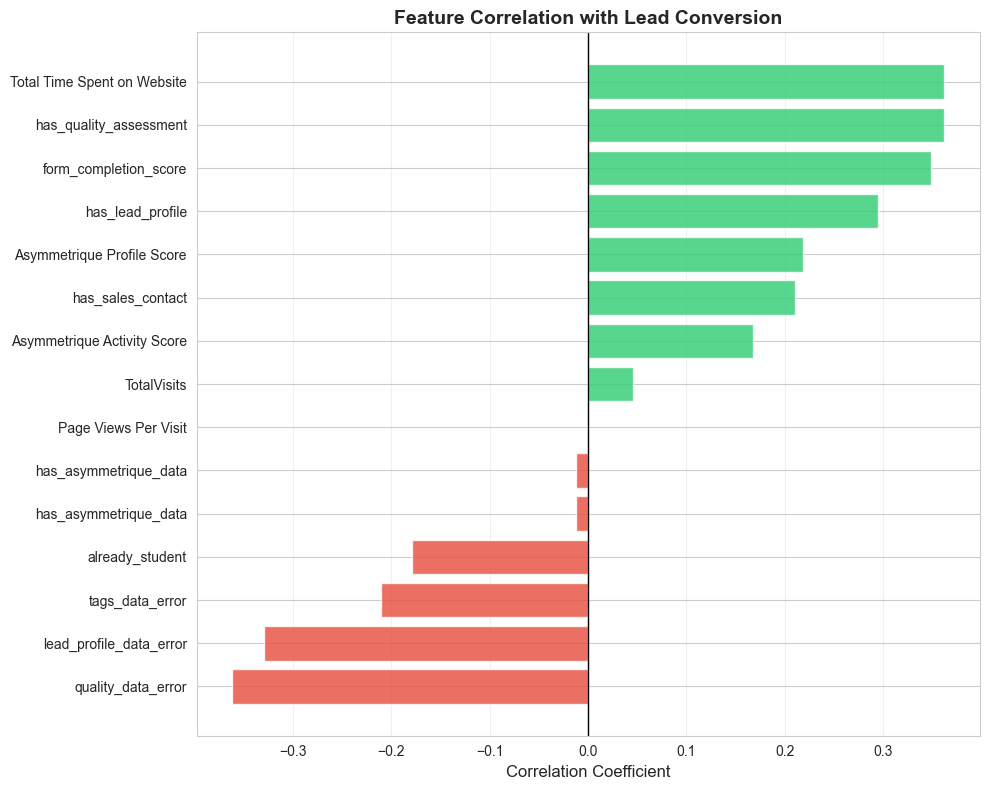


✓ Saved: visualizations/06_feature_correlations.png


In [15]:
# Correlation with conversion
print("=" * 80)
print("FEATURE CORRELATION WITH CONVERSION")
print("=" * 80)

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove ID columns and target
exclude_cols = ['Prospect ID', 'Lead Number', 'Converted']
feature_cols = [col for col in numerical_cols if col not in exclude_cols]

# Calculate correlations
if feature_cols:
    correlations = df[feature_cols + ['Converted']].corr()['Converted'].drop('Converted').sort_values(ascending=False)
    
    print("\nTop 15 Positive Correlations:")
    print(correlations.head(15))
    
    print("\nTop 5 Negative Correlations:")
    print(correlations.tail(5))
    
    # Visualize top correlations
    fig, ax = plt.subplots(figsize=(10, 8))
    
    top_corr = pd.concat([correlations.head(10), correlations.tail(5)])
    colors_corr = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr]
    
    ax.barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.8)
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index)
    ax.set_xlabel('Correlation Coefficient', fontsize=12)
    ax.set_title('Feature Correlation with Lead Conversion', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('../visualizations/06_feature_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Saved: visualizations/06_feature_correlations.png")

## 8. Data Quality Impact

How do data quality flags correlate with conversion?

In [16]:
# Data quality flags analysis
print("=" * 80)
print("DATA QUALITY FLAGS IMPACT")
print("=" * 80)

quality_flags = [
    'lead_profile_data_error',
    'quality_data_error',
    'tags_data_error'
]

available_flags = [f for f in quality_flags if f in df.columns]

if available_flags:
    print("\nConversion rates by data quality:")
    
    for flag in available_flags:
        flag_analysis = df.groupby(flag)['Converted'].agg(['count', 'mean'])
        flag_analysis.columns = ['Total_Leads', 'Conversion_Rate']
        flag_analysis['Conversion_Pct'] = (flag_analysis['Conversion_Rate'] * 100).round(2)
        flag_analysis.index = ['Clean Data', 'Data Error']
        
        print(f"\n{flag.replace('_', ' ').title()}:")
        print(flag_analysis)
        
        if len(flag_analysis) > 1:
            clean_conv = flag_analysis.loc['Clean Data', 'Conversion_Pct']
            error_conv = flag_analysis.loc['Data Error', 'Conversion_Pct']
            print(f"  Impact: {clean_conv - error_conv:+.1f}% difference")

DATA QUALITY FLAGS IMPACT

Conversion rates by data quality:

Lead Profile Data Error:
            Total_Leads  Conversion_Rate  Conversion_Pct
Clean Data         6531         0.488593           48.86
Data Error         2709         0.136582           13.66
  Impact: +35.2% difference

Quality Data Error:
            Total_Leads  Conversion_Rate  Conversion_Pct
Clean Data         4473         0.567181           56.72
Data Error         4767         0.214810           21.48
  Impact: +35.2% difference

Tags Data Error:
            Total_Leads  Conversion_Rate  Conversion_Pct
Clean Data         5887         0.462884           46.29
Data Error         3353         0.249329           24.93
  Impact: +21.4% difference


## 9. Lead Profile & Quality Analysis

In [17]:
# Lead Profile analysis
print("=" * 80)
print("LEAD PROFILE PERFORMANCE")
print("=" * 80)

if 'Lead Profile' in df.columns:
    # Exclude data errors and "To Be Determined" for fair comparison
    valid_profiles = df[~df['Lead Profile'].isin(['Data Error', 'To Be Determined'])]
    
    if len(valid_profiles) > 0:
        profile_analysis = valid_profiles.groupby('Lead Profile').agg({
            'Converted': ['count', 'sum', 'mean']
        }).round(3)
        
        profile_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
        profile_analysis['Conversion_Pct'] = (profile_analysis['Conversion_Rate'] * 100).round(2)
        profile_analysis = profile_analysis.sort_values('Conversion_Pct', ascending=False)
        
        print("\nConversion by Lead Profile (Valid Categories Only):")
        print(profile_analysis)

LEAD PROFILE PERFORMANCE

Conversion by Lead Profile (Valid Categories Only):
                             Total_Leads  Conversions  Conversion_Rate  \
Lead Profile                                                             
Dual Specialization Student           20           20            1.000   
Lateral Student                       24           23            0.958   
Potential Lead                      1613         1267            0.785   
Other Leads                          487          180            0.370   
Student of SomeSchool                241            9            0.037   

                             Conversion_Pct  
Lead Profile                                 
Dual Specialization Student           100.0  
Lateral Student                        95.8  
Potential Lead                         78.5  
Other Leads                            37.0  
Student of SomeSchool                   3.7  



LEAD QUALITY ASSESSMENT PERFORMANCE

Conversion by Lead Quality (Assessed Leads Only):
                   Total_Leads  Conversions  Conversion_Rate  Conversion_Pct
Lead Quality                                                                
High in Relevance          637          603            0.947            94.7
Low in Relevance           583          477            0.818            81.8
Might be                  1560         1179            0.756            75.6
Not Sure                  1092          266            0.244            24.4
Worst                      601           12            0.020             2.0


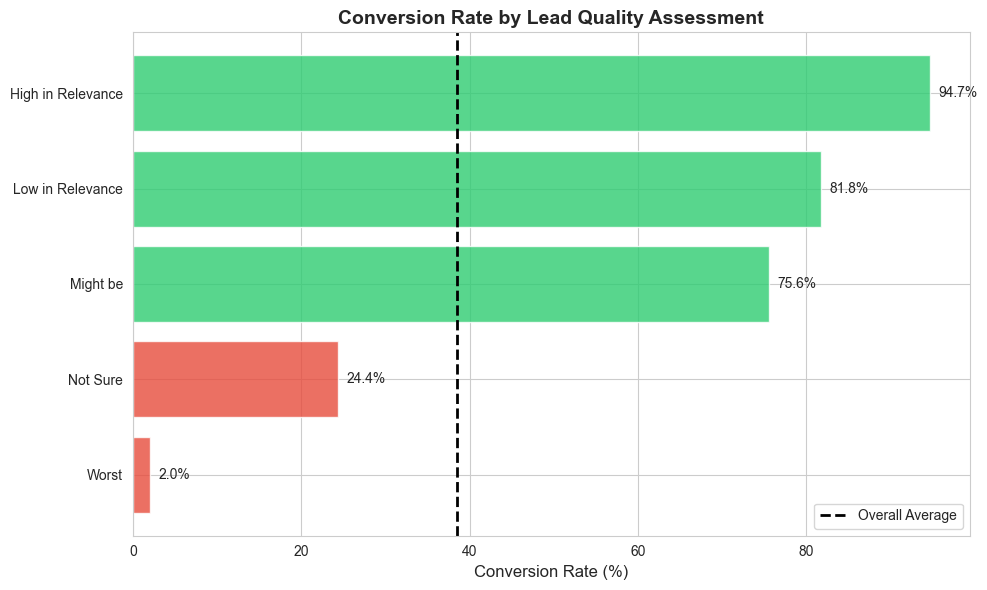


✓ Saved: visualizations/07_lead_quality_conversion.png


In [19]:
# Lead Quality analysis
print("\n" + "=" * 80)
print("LEAD QUALITY ASSESSMENT PERFORMANCE")
print("=" * 80)

if 'Lead Quality' in df.columns:
    # Exclude data errors for fair comparison
    valid_quality = df[df['Lead Quality'] != 'Data Error']
    
    if len(valid_quality) > 0:
        quality_analysis = valid_quality.groupby('Lead Quality').agg({
            'Converted': ['count', 'sum', 'mean']
        }).round(3)
        
        quality_analysis.columns = ['Total_Leads', 'Conversions', 'Conversion_Rate']
        quality_analysis['Conversion_Pct'] = (quality_analysis['Conversion_Rate'] * 100).round(2)
        quality_analysis = quality_analysis.sort_values('Conversion_Pct', ascending=False)
        
        print("\nConversion by Lead Quality (Assessed Leads Only):")
        print(quality_analysis)
        
        # Visualize
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors_quality = ['#2ecc71' if x > conversion_rate else '#e74c3c' for x in quality_analysis['Conversion_Pct']]
        ax.barh(range(len(quality_analysis)), quality_analysis['Conversion_Pct'], color=colors_quality, alpha=0.8)
        ax.set_yticks(range(len(quality_analysis)))
        ax.set_yticklabels(quality_analysis.index)
        ax.set_xlabel('Conversion Rate (%)', fontsize=12)
        ax.set_title('Conversion Rate by Lead Quality Assessment', fontsize=14, fontweight='bold')
        ax.axvline(x=conversion_rate, color='black', linestyle='--', linewidth=2, label='Overall Average')
        ax.legend()
        ax.invert_yaxis()
        
        # Add percentage labels
        for i, v in enumerate(quality_analysis['Conversion_Pct']):
            ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
        
        plt.tight_layout()
        plt.savefig('../visualizations/07_lead_quality_conversion.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Saved: visualizations/07_lead_quality_conversion.png")

We are either in front of wrong calculation for the lead quality or we underestimate the conversion for the low in relevance and might be. Maybe a scoring method would be more appropriate to estimate the lead quality

## 10. Key Insights Summary

In [20]:
print("=" * 80)
print("KEY INSIGHTS FROM EXPLORATORY ANALYSIS")
print("=" * 80)

insights = f"""
📊 DATASET OVERVIEW:
- Total Leads: {len(df):,}
- Overall Conversion Rate: {conversion_rate:.2f}%
- Features Available: {len(df.columns)}

🎯 STRONGEST CONVERSION PREDICTORS:

1. FORM COMPLETION (Most Important!):
   - Complete forms convert at ~{complete_forms:.1f}%
   - Incomplete forms convert at ~{incomplete_forms:.1f}%
   - This is a {multiplier:.1f}x difference!
   - Action: Encourage form completion, follow up on incomplete leads

2. SALES ENGAGEMENT:
   - Contacted leads show different conversion patterns
   - Action status provides clear signals
   - "In Discussion" status shows engagement level

3. BEHAVIORAL SIGNALS:
   - Total visits, time spent, page views all correlate with conversion
   - Converted leads show higher engagement across all metrics
   - Action: Use behavioral thresholds for lead scoring

4. LEAD SOURCE:
   - Significant variation in conversion by source
   - Some sources deliver 2-3x better conversion
   - Action: Optimize marketing spend toward high-converting sources

💡 DATA QUALITY INSIGHTS:
- Data quality flags correlate with conversion
- Clean data leads perform differently than error-flagged leads
- This validates the need for engineering fixes

🎯 MODELING IMPLICATIONS:

HIGH-VALUE FEATURES TO INCLUDE:
- form_completion_score (CRITICAL)
- Behavioral metrics (visits, time, pages)
- action_status (sales engagement)
- Lead Source (channel quality)
- has_sales_contact (engagement flag)

FEATURES TO CONSIDER:
- Lead Quality (when assessed)
- Lead Profile (when categorized)
- Data quality flags (as signals)

LEADS TO POTENTIALLY EXCLUDE:
- Already a student ({df['already_student'].sum() if 'already_student' in df.columns else 0} leads)
- Consider excluding for cleaner model training

✅ NEXT STEP: Build lead scoring model in Notebook 02
"""

print(insights)

KEY INSIGHTS FROM EXPLORATORY ANALYSIS

📊 DATASET OVERVIEW:
- Total Leads: 9,240
- Overall Conversion Rate: 38.54%
- Features Available: 47

🎯 STRONGEST CONVERSION PREDICTORS:

1. FORM COMPLETION (Most Important!):
   - Complete forms convert at ~68.4%
   - Incomplete forms convert at ~10.6%
   - This is a 6.5x difference!
   - Action: Encourage form completion, follow up on incomplete leads

2. SALES ENGAGEMENT:
   - Contacted leads show different conversion patterns
   - Action status provides clear signals
   - "In Discussion" status shows engagement level

3. BEHAVIORAL SIGNALS:
   - Total visits, time spent, page views all correlate with conversion
   - Converted leads show higher engagement across all metrics
   - Action: Use behavioral thresholds for lead scoring

4. LEAD SOURCE:
   - Significant variation in conversion by source
   - Some sources deliver 2-3x better conversion
   - Action: Optimize marketing spend toward high-converting sources

💡 DATA QUALITY INSIGHTS:
- Data 

## 11. Prepare for Modeling

Save key insights for model building.

In [22]:
# Save exploration summary
exploration_summary = {
    'total_leads': int(len(df)),  # Convert to Python int
    'conversion_rate': float(conversion_rate),  # Convert to Python float
    'form_completion_impact': {
        'complete_forms_conversion': float(complete_forms),
        'incomplete_forms_conversion': float(incomplete_forms),
        'multiplier': float(multiplier)
    },
    'high_value_features': [
        'form_completion_score',
        'TotalVisits',
        'Total Time Spent on Website',
        'Page Views Per Visit',
        'action_status',
        'Lead Source',
        'has_sales_contact'
    ],
    'leads_to_exclude': {
        'already_student': int(df['already_student'].sum()) if 'already_student' in df.columns else 0
    }
}

import json
with open('../data/exploration_summary.json', 'w') as f:
    json.dump(exploration_summary, f, indent=2)

print("=" * 80)
print("EXPLORATION COMPLETE")
print("=" * 80)
print("\n✓ Exploration summary saved to: data/exploration_summary.json")
print("✓ Visualizations saved to: visualizations/")
print("\n🚀 Ready for Notebook 02 - Lead Scoring Model!")

EXPLORATION COMPLETE

✓ Exploration summary saved to: data/exploration_summary.json
✓ Visualizations saved to: visualizations/

🚀 Ready for Notebook 02 - Lead Scoring Model!


## ✅ Exploration Complete!

this analysis reveals also a classic **missed opportunity**:

**The Problem:**
- We're successfully driving traffic through high-volume channels (Olark Chat, Direct Traffic)
- But we're FAILING to convert that traffic
- This is like having a store full of customers but poor salespeople

**Why This is Critical:**
- **Acquisition costs are sunk** - we've already paid to get these leads
- **Low-hanging fruit** - fixing conversion is easier than finding new channels
- **Immediate ROI** - no need to wait for new campaigns to ramp up

**The CRM Fix:**
1. **Olark Chat:** Implement qualification workflow, improve routing, optimize scripts
2. **Direct Traffic:** Optimize landing experience, implement progressive profiling
3. **Both:** Set up automated nurture sequences for unqualified leads
